# Generate G2 phase diagram from Holland et al. (2018)
## Part 2 : Import MAGEMin output

**This notebook must be run with python**

In [1]:
import pyMelt as m
from pyMelt import phaseDiagramTools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
results = pd.read_csv('table_g2_holland2018.csv')
results.head()

,P,T,spn_wtpt_O,spn,spn_wtpt_FeO,opx,heat_capacity,cpx_cbuf,ol_wtpt_H2O,cpx_cfs,...,g_wtpt_H2O,g_wtpt_FeO,g_wtpt_O,g_wtpt_SiO2,g_wtpt_Na2O,g_knom,ru,q,ky,coe
0,0.01,1000.000000,0.327579,0.049193,46.429972,0.027275,0.287070,0.021904,0.0,0.235207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.01,1003.212851,0.328164,0.049173,46.422479,0.026110,0.287439,0.022000,0.0,0.235477,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.01,1006.425703,0.328517,0.049156,46.411465,0.024912,0.287331,0.022101,0.0,0.235724,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.01,1009.638554,0.329428,0.049146,46.399070,0.023691,0.287638,0.022203,0.0,0.235924,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.01,1012.851406,0.329250,0.049123,46.387062,0.022418,0.287616,0.022313,0.0,0.236193,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Format the data table

Replace thermocalc phase nomenclature with pyMelt nomenclature:

In [3]:
for col in results.columns:
    if col.split('_')[0] == 'ol':
        # print('olv'+col[2:])
        results['olv'+col[2:]] = results[col]
        results.drop(col, axis=1, inplace=True)
    elif col.split('_')[0] == 'g':
        results['grt'+col[1:]] = results[col]
        results.drop(col, axis=1, inplace=True)
    elif col.split('_')[0] == 'fsp':
        results['plg'+col[3:]] = results[col]
        results.drop(col, axis=1, inplace=True)

Remove H2O (which should all be 0):

In [4]:
for col in results.columns:
    if col.split('_')[-1] == 'H2O':
        results.drop(col, axis=1, inplace=True)

Replace O with Fe2O3:

In [5]:
for col in results.columns:
    cs = col.split('_')
    if cs[-1] == 'O':
        results[cs[0] + '_wtpt_FeO'] = (results[cs[0] + '_wtpt_FeO'] / 71.844 - results[cs[0] + '_wtpt_O'] / 15.999 * 2) * 71.844
        results[cs[0] + '_wtpt_Fe2O3'] = results[cs[0] + '_wtpt_O'] / 15.999 * 159.69
        results.drop(col, axis=1, inplace=True)


Relabel temperature and pressure:

In [6]:
results['temperature'] = results['T']
results.drop('T', axis=1, inplace=True)
results['pressure'] = results['P']
results.drop('P', axis=1, inplace=True)

Reorder wtpt labels:

In [7]:
for col in results.columns:
    cs = col.split('_')
    if len(cs) > 1 and cs[1] == 'wtpt':
        results[cs[0] + '_' + cs[2] + '_wtpt'] = results[col]
        results.drop(col, axis=1, inplace=True)

In [8]:
for col in results.columns:
    if col in ['olv', 'cpx', 'opx', 'grt', 'spn', 'plg', 'liq','ru','q','coe','ilm']:
        results[col + '_mass'] = results[col]
        results.drop(col, axis=1, inplace=True)

/var/folders/n0/svdqwyps7dn84jf04d055ywh0000gn/T/ipykernel_55420/1258537370.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[col + '_mass'] = results[col]
/var/folders/n0/svdqwyps7dn84jf04d055ywh0000gn/T/ipykernel_55420/1258537370.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[col + '_mass'] = results[col]
/var/folders/n0/svdqwyps7dn84jf04d055ywh0000gn/T/ipykernel_55420/1258537370.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Replace zeros with NaN so the algorithm recognises the start and end of phase presence etc.

In [9]:
results.replace(0.0, np.nan, inplace=True)

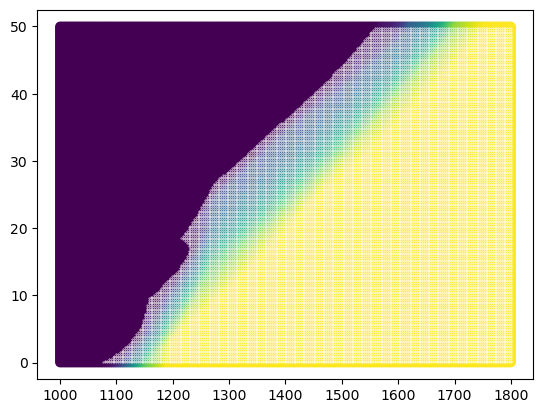

In [10]:
# f,a = plt.subplots()

# a.scatter(results.temperature, results.pressure, c=results.liq_mass)
# a.scatter(results.temperature[results.liq_mass>0][results.pressure<50.0], 
#           results.pressure[results.liq_mass>0][results.pressure<50.0], c='w', s=0.11)


# plt.show()

In [10]:
results = results[results.pressure<50.0]

### Import into pyMelt

In [11]:
grid = phaseDiagramTools.gridsMAGEMin(results)

In [12]:
phasediagram = phaseDiagramTools.phaseDiagram(grid, minerals=['olv', 'cpx', 'opx', 'grt', 'spn', 'plg','ru','q','coe','ilm'])

In [13]:
f = open( "g2_holland2018.p", "wb" )
pickle.dump(phasediagram, f)
f.close()

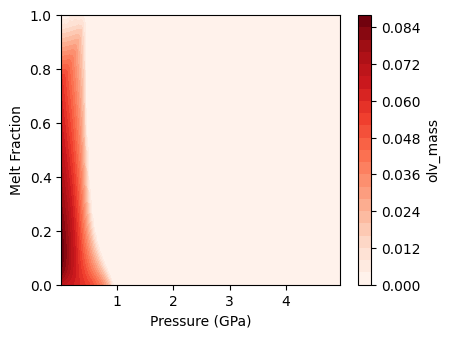

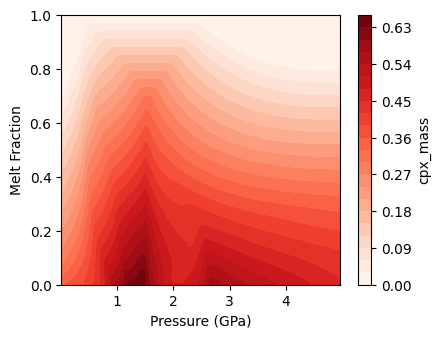

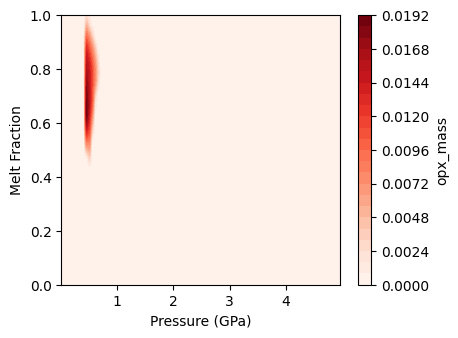

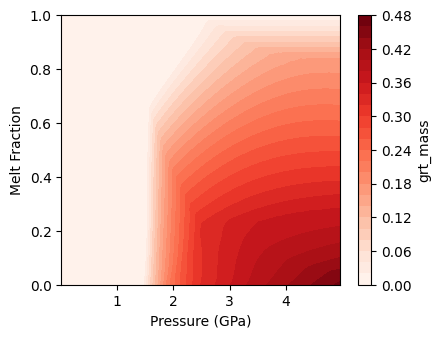

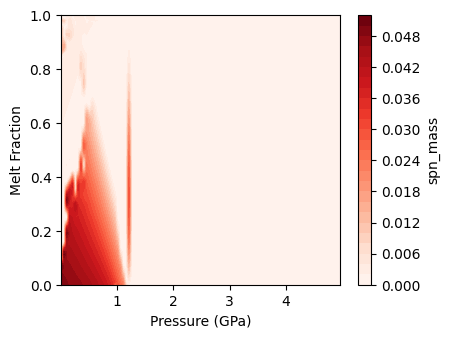

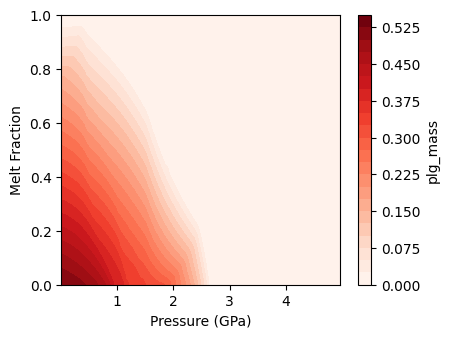

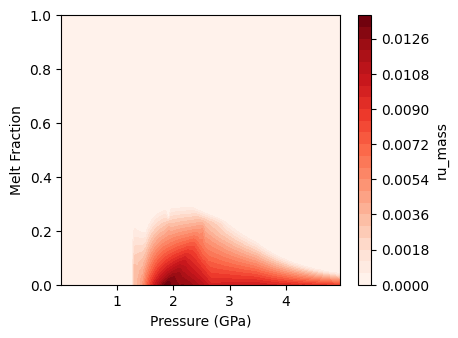

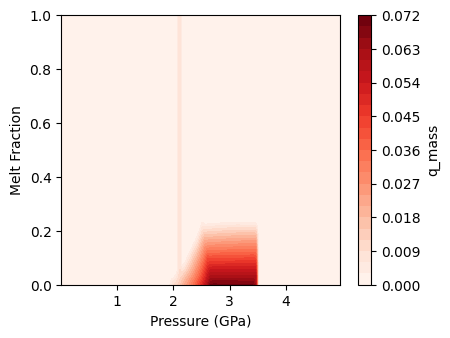

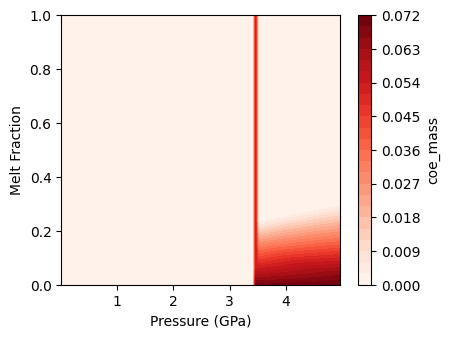

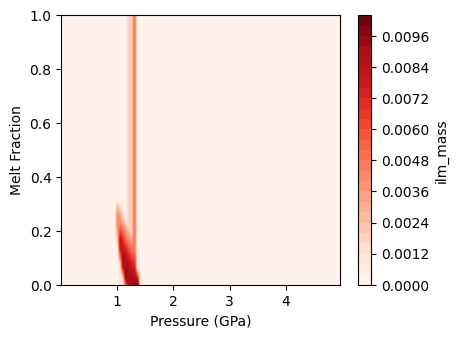

In [14]:
# phases = ['olv', 'cpx', 'opx', 'grt', 'spn', 'plg','ru','q','coe','ilm']

# for ph in phases:
#     f, a = phasediagram.plot_TxSection(ph + '_mass', mask_mineral_out=False)
#     plt.show()

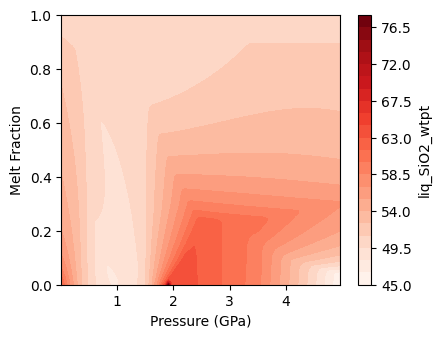

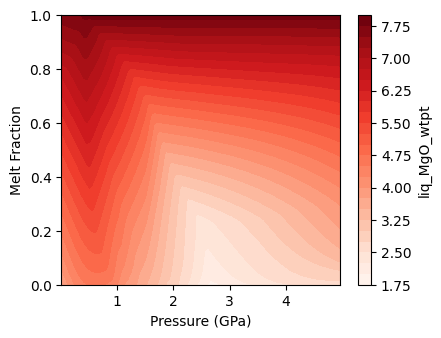

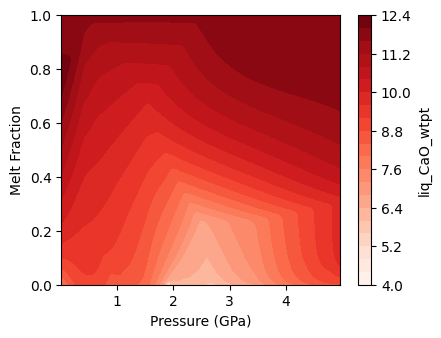

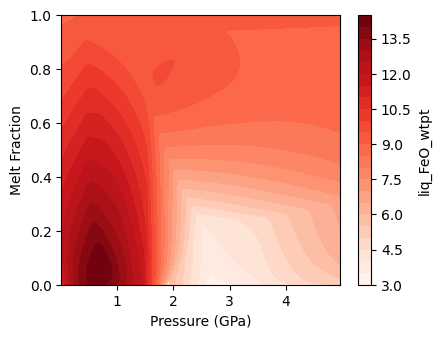

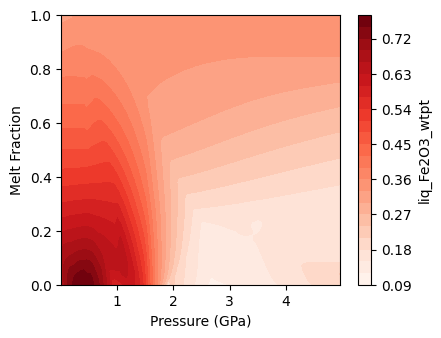

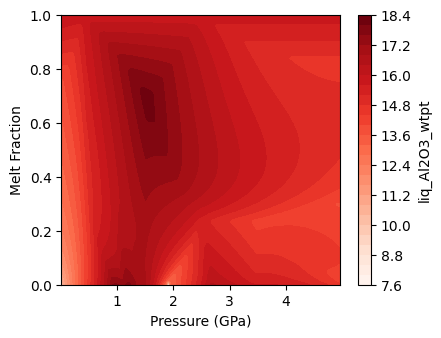

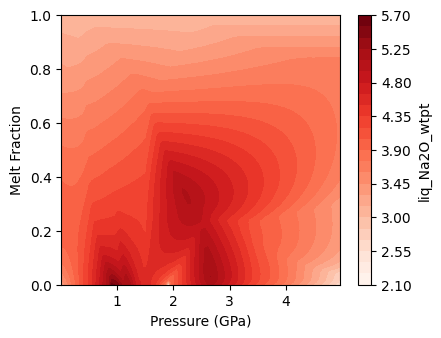

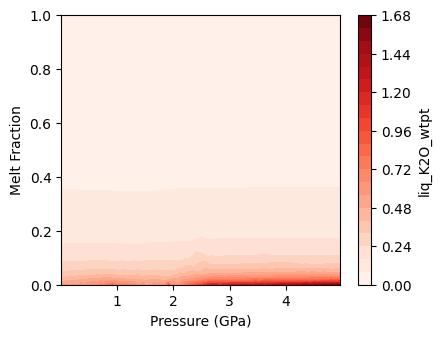

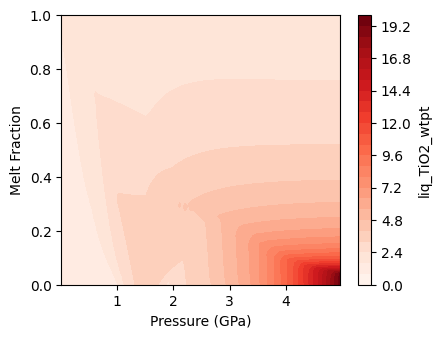

In [15]:
# oxides = ['SiO2', 'MgO', 'CaO', 'FeO', 'Fe2O3', 'Al2O3', 'Na2O', 'K2O', 'TiO2']

# for ox in oxides:
#     f, a = phasediagram.plot_TxSection('liq_' + ox + '_wtpt')
#     plt.show()
